# Dissipative Forces

galpy supports velocity-dependent (dissipative) forces that can be combined
with regular gravitational potentials for orbit integration. These are
implemented as subclasses of `DissipativeForce`.

<div class="alert alert-warning">

**Warning**

Dissipative forces only work in 3D orbit integration.

</div>

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    MWPotential2014,
    LogarithmicHaloPotential,
    ChandrasekharDynamicalFrictionForce,
)
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Chandrasekhar Dynamical Friction

`ChandrasekharDynamicalFrictionForce` implements the classical Chandrasekhar
dynamical-friction formula. It requires a background potential (whose density
is used to compute the local density) and the mass of the sinking object.

In [2]:
from astropy import units as u

# Logarithmic halo as the host
lp = LogarithmicHaloPotential(normalize=1.0, q=1.0)

# Dynamical friction from a satellite of mass 5e10 Msun
cdf = ChandrasekharDynamicalFrictionForce(
    GMs=0.5,  # satellite mass in natural units (fraction of v_0^2 * R_0)
    rhm=0.125,  # half-mass radius of the satellite
    dens=lp,  # background density from this potential
)

print(type(cdf))

<class 'galpy.potential.ChandrasekharDynamicalFrictionForce.ChandrasekharDynamicalFrictionForce'>


Now integrate an orbit with and without dynamical friction to see the effect:

In [3]:
# Integrate an orbit with and without dynamical friction
o_nodf = Orbit([1.5, 0.1, 0.8, 0.0, 0.0, 0.0])
o_df = Orbit([1.5, 0.1, 0.8, 0.0, 0.0, 0.0])

ts = numpy.linspace(0.0, 30.0, 10001)

# Without friction
o_nodf.integrate(ts, lp)
# With friction: combine potential + dissipative force
o_df.integrate(ts, lp + cdf)

Compare the orbital radius over time:

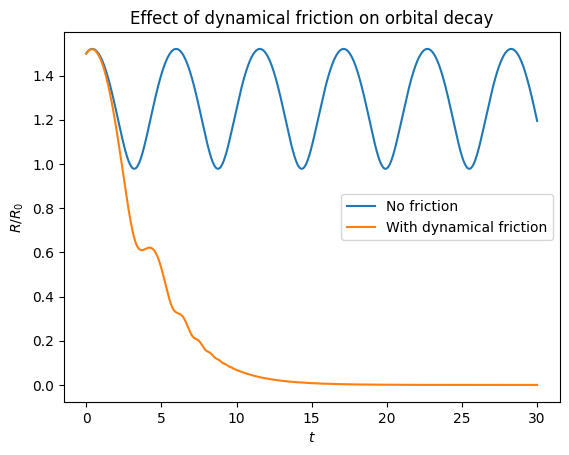

In [4]:
# Compare the orbital radius over time
plt.plot(ts, o_nodf.R(ts), label="No friction")
plt.plot(ts, o_df.R(ts), label="With dynamical friction")
plt.xlabel(r"$t$")
plt.ylabel(r"$R / R_0$")
plt.legend()
plt.title("Effect of dynamical friction on orbital decay");

The orbit in the x-y plane clearly shows the inspiral with friction:

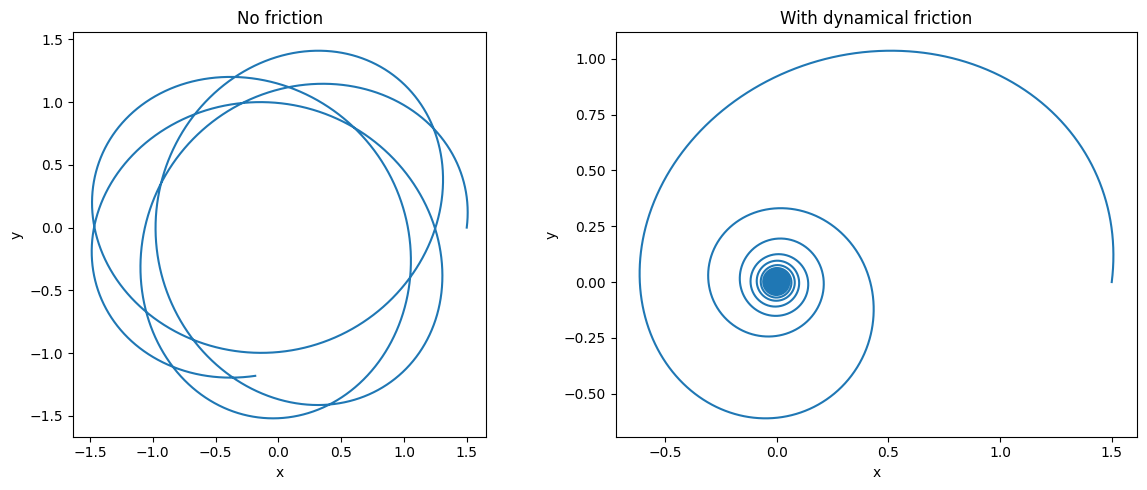

In [5]:
# Plot the orbit in x-y
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(o_nodf.x(ts), o_nodf.y(ts))
axes[0].set_title("No friction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[1].plot(o_df.x(ts), o_df.y(ts))
axes[1].set_title("With dynamical friction")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.tight_layout();

## Energy dissipation

We can verify that dynamical friction removes energy from the orbit:

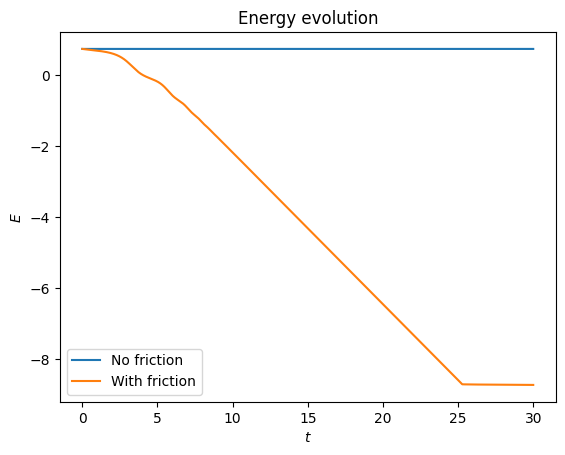

In [6]:
plt.plot(ts, o_nodf.E(ts, pot=lp), label="No friction")
plt.plot(ts, o_df.E(ts, pot=lp), label="With friction")
plt.xlabel(r"$t$")
plt.ylabel(r"$E$")
plt.legend()
plt.title("Energy evolution");

## NonInertialFrameForce

galpy also provides `NonInertialFrameForce` for integrating orbits in
non-inertial (e.g., rotating or accelerating) reference frames. This is
covered in detail in the [Integration and Plotting](../orbits/integration_and_plotting.ipynb)
tutorial, since it is most naturally used in the context of orbit integration.

Key points:
- It adds fictitious forces (Coriolis, centrifugal, etc.)
- Specified via `Omega` (rotation) and/or `a0` (linear acceleration)
- 3D only, like all dissipative forces

For basic potential usage, see the [Introduction to Potentials](introduction.ipynb).

## Example: Schwarzschild precession of the S2 orbit around Sgr A*

The S2 star orbits the supermassive black hole Sgr A* at the Galactic Center on a highly eccentric orbit with a 16-year period. The [GRAVITY Collaboration (2020)](https://arxiv.org/abs/2004.07187) detected the **Schwarzschild precession** of S2's orbit -- the relativistic precession of the pericenter due to the GR correction to the Kepler potential. Here we reproduce this calculation using galpy by adding the first-order GR correction, which is a velocity-dependent force, to a `KeplerPotential` (note that it is not dissipative, just velocity-dependent).

We use [rebound](https://rebound.readthedocs.io/) to convert S2's orbital elements (semi-major axis, eccentricity, inclination, argument of pericenter, longitude of ascending node, time of pericenter) to a Cartesian position and velocity that can initialize a galpy `Orbit`.

In [7]:
import rebound
import astropy.units as u
from astropy.constants import c as c_si
from galpy.potential import KeplerPotential
from galpy.potential.DissipativeForce import DissipativeForce

c_kms = c_si.to_value(u.km / u.s)

# Sgr A* parameters
R0 = 8246.7 * u.pc
vo = 220.0 * u.km / u.s
MSgrA = 4.261e6 * u.Msun

# Set up a rebound simulation with S2's orbital elements (GRAVITY Collaboration 2020)
sim = rebound.Simulation()
sim.units = ("AU", "yr", "Msun")
sim.add(m=MSgrA.to_value(u.Msun))  # Sgr A*
sim.add(
    m=0.0,
    a=(125.058 * u.mas * R0).to_value(u.AU, equivalencies=u.dimensionless_angles()),
    e=0.884649,
    inc=(134.567 * u.deg).to_value(u.rad),
    omega=(66.263 * u.deg).to_value(u.rad),
    Omega=(228.171 * u.deg).to_value(u.rad),
    T=(8.37900 * u.yr).to_value(u.yr) - 0.35653101,  # time since 2010's apocenter
)
print(f"S2 semi-major axis = {sim.particles[1].a:.1f} AU, e = {sim.particles[1].e:.3f}")

S2 semi-major axis = 1031.3 AU, e = 0.885


Initialize a galpy `Orbit` from the rebound Cartesian position and velocity, then integrate it in a `KeplerPotential` representing Sgr A*:

In [8]:
pt = sim.particles[1]
# Sgr A* at the Galactic Center as the reference point
ogc = Orbit([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], ro=R0, vo=vo)
ra_gc, dec_gc = ogc.ra(), ogc.dec()  # degrees (floats)


# Convert rebound Cartesian to (RA, Dec, dist, pmRA, pmDec, vlos) offsets
def make_s2_orbit():
    return Orbit(
        [
            ra_gc * u.deg
            + (pt.y * u.AU / R0).to(u.deg, equivalencies=u.dimensionless_angles()),
            dec_gc * u.deg
            + (pt.x * u.AU / R0).to(u.deg, equivalencies=u.dimensionless_angles()),
            ogc.dist() * u.kpc + pt.z * u.AU,
            ogc.pmra() * u.mas / u.yr
            + (pt.vy * u.AU / u.yr / R0).to(
                u.mas / u.yr, equivalencies=u.dimensionless_angles()
            ),
            ogc.pmdec() * u.mas / u.yr
            + (pt.vx * u.AU / u.yr / R0).to(
                u.mas / u.yr, equivalencies=u.dimensionless_angles()
            ),
            ogc.vlos() * u.km / u.s + pt.vz * u.AU / u.yr,
        ],
        radec=True,
        ro=R0,
        vo=vo,
    )


kp = KeplerPotential(amp=MSgrA, ro=R0)
times = numpy.linspace(0.0, 4.0 * 16.0455, 1001) * u.yr  # 4 orbital periods

o = make_s2_orbit()
o.integrate(times, kp)

To compute the Schwarzschild precession we implement the leading-order GR correction as a `DissipativeForce` (which is the galpy class for velocity-dependent forces):

$$
\vec{a}_{\mathrm{SP}} = f_{\mathrm{SP}}\,\frac{GM}{c^2 r^2}\left[\left(2(\gamma+\beta)\,\frac{GM}{r} - \gamma\,v^2\right)\frac{\vec{r}}{r} + 2(1+\gamma)\,v_r\,\vec{v}\right].
$$

The factor $f_{\mathrm{SP}}$ is the "GR factor" used by GRAVITY Collaboration (2020) -- $f_{\mathrm{SP}} = 1$ corresponds to standard GR. The PPN parameters $\gamma$ and $\beta$ default to their GR values ($\gamma = \beta = 1$).

In [9]:
class SchwarzschildPrecessionForce(DissipativeForce):
    def __init__(self, amp=1.0, fsp=1.0, gamma=1.0, beta=1.0, ro=None, vo=None):
        DissipativeForce.__init__(self, amp=amp, ro=ro, vo=vo, amp_units="mass")
        self._fsp = fsp
        self._gamma = gamma
        self._beta = beta

    def _force_firstterm(self, r, v):
        return (
            1.0
            / (c_kms / self._vo) ** 2
            / r**3
            * (2.0 * (self._gamma + self._beta) * self._amp / r - self._gamma * v**2)
        )

    def _force_secondterm(self, r, vr):
        return 2.0 * (1.0 + self._gamma) / (c_kms / self._vo) ** 2 / r**2 * vr

    def _Rforce(self, R, z, phi=0.0, t=0.0, v=None):
        r = numpy.sqrt(R**2 + z**2)
        vr = R / r * v[0] + z / r * v[2]
        vmag = numpy.sqrt(v[0] ** 2 + v[1] ** 2 + v[2] ** 2)
        return self._fsp * (
            self._force_firstterm(r, vmag) * R + self._force_secondterm(r, vr) * v[0]
        )

    def _zforce(self, R, z, phi=0.0, t=0.0, v=None):
        r = numpy.sqrt(R**2 + z**2)
        vr = R / r * v[0] + z / r * v[2]
        vmag = numpy.sqrt(v[0] ** 2 + v[1] ** 2 + v[2] ** 2)
        return self._fsp * (
            self._force_firstterm(r, vmag) * z + self._force_secondterm(r, vr) * v[2]
        )

    def _phitorque(self, R, z, phi=0.0, t=0.0, v=None):
        r = numpy.sqrt(R**2 + z**2)
        vr = R / r * v[0] + z / r * v[2]
        return self._fsp * (self._force_secondterm(r, vr) * v[1] * R)

To make the precession clearly visible over just a few orbits, we exaggerate it with $f_{\mathrm{SP}} = 5$. We integrate the same initial conditions in the Kepler potential plus the precession force and compare:

In [10]:
sp = SchwarzschildPrecessionForce(amp=MSgrA, ro=R0, fsp=5.0)

osp = make_s2_orbit()
osp.integrate(times, kp + sp)

Plot the orbit as $\Delta\mathrm{Dec}$ vs. $\Delta\mathrm{RA}$ relative to Sgr A*. The Newtonian Kepler orbit is a closed ellipse, while the GR orbit precesses, tracing out a rosette:

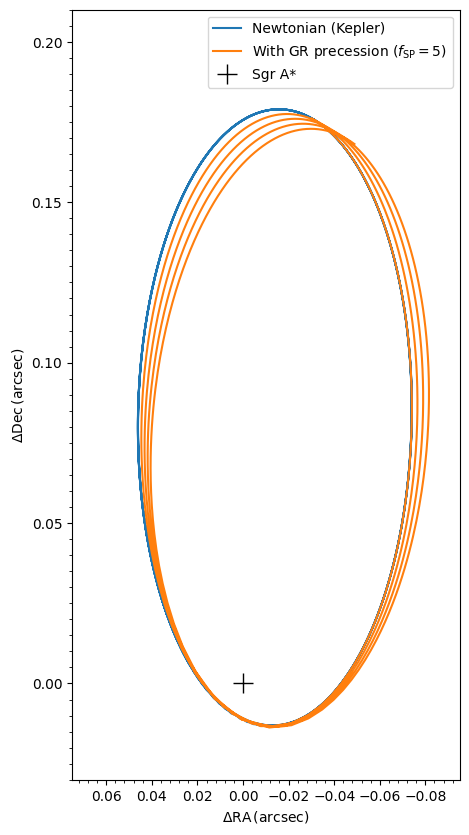

In [11]:
plt.figure(figsize=(5, 10))
o.plot(
    d1=f"(ra-{ra_gc})*3600",
    d2=f"(dec-{dec_gc})*3600",
    xlabel=r"$\Delta\mathrm{RA}\,(\mathrm{arcsec})$",
    ylabel=r"$\Delta\mathrm{Dec}\,(\mathrm{arcsec})$",
    label="Newtonian (Kepler)",
    gcf=True,
)
osp.plot(
    d1=f"(ra-{ra_gc})*3600",
    d2=f"(dec-{dec_gc})*3600",
    overplot=True,
    label=r"With GR precession ($f_{\mathrm{SP}}=5$)",
)
plt.plot([0], [0], "k+", ms=15, label="Sgr A*")
plt.xlim(0.075, -0.095)
plt.ylim(-0.03, 0.21)
plt.legend(fontsize=10);

The pericenter advances by a few degrees per orbit, exactly the relativistic effect detected by GRAVITY Collaboration (2020). With the actual GR value $f_{\mathrm{SP}} = 1$ the precession is five times smaller -- still measurable with high-precision astrometry, but harder to see in a plot of just a few orbits.

Finally, let's check that when setting $\beta = 2(1+\gamma) = 4$ for $\gamma = 1$ we get zero precession (a useful sanity check on the PPN form of the precession formula):

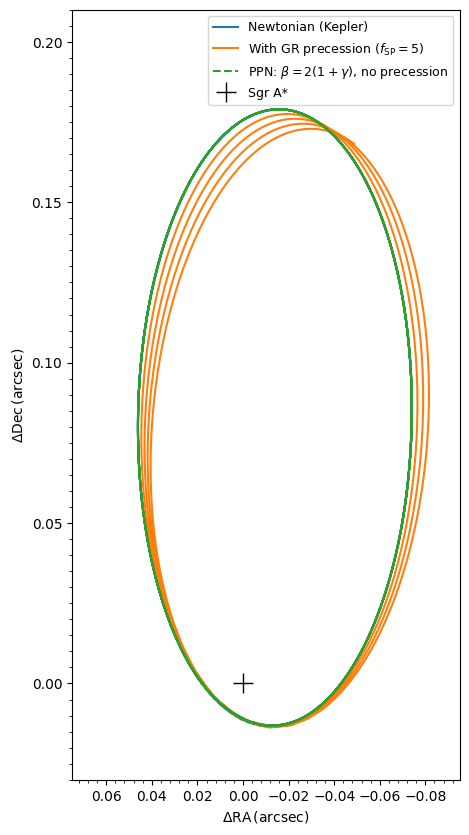

In [12]:
spzero = SchwarzschildPrecessionForce(amp=MSgrA, ro=R0, fsp=1.0, beta=4.0, gamma=1.0)
ozero = make_s2_orbit()
ozero.integrate(times, kp + spzero)

plt.figure(figsize=(5, 10))
o.plot(
    d1=f"(ra-{ra_gc})*3600",
    d2=f"(dec-{dec_gc})*3600",
    xlabel=r"$\Delta\mathrm{RA}\,(\mathrm{arcsec})$",
    ylabel=r"$\Delta\mathrm{Dec}\,(\mathrm{arcsec})$",
    label="Newtonian (Kepler)",
    gcf=True,
)
osp.plot(
    d1=f"(ra-{ra_gc})*3600",
    d2=f"(dec-{dec_gc})*3600",
    overplot=True,
    label=r"With GR precession ($f_{\mathrm{SP}}=5$)",
)
ozero.plot(
    d1=f"(ra-{ra_gc})*3600",
    d2=f"(dec-{dec_gc})*3600",
    overplot=True,
    ls="--",
    label=r"PPN: $\beta=2(1+\gamma)$, no precession",
)
plt.plot([0], [0], "k+", ms=15, label="Sgr A*")
plt.xlim(0.075, -0.095)
plt.ylim(-0.03, 0.21)
plt.legend(fontsize=9);

As expected, the dashed PPN curve traces the same closed ellipse as the Newtonian orbit -- the choice $\beta = 2(1+\gamma)$ exactly cancels the pericenter precession.